In [110]:
# =========================================================
# Import Required Libraries
# =========================================================
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
import pandas as pd

In [111]:
# =========================================================
# Dataset
# =========================================================
df = pd.DataFrame({
    "soil_moisture": [0.10, 0.15, 0.20, 0.25, 0.40, 0.60, 0.35, 0.18,
                      0.45, 0.05, 0.80, 0.27, 0.55, 0.70, 0.12, 0.30],
    "temperature_c": [34, 30, 26, 22, 28, 30, 19, 22,
                      35, 24, 33, 33, 21, 25, 20, 29],
    "sunlight_hours": [9, 8, 7, 4, 8, 10, 3, 10,
                       12, 5, 9, 11, 2, 6, 1, 9],
    "needs_water": [1, 1, 1, 0, 0, 0, 0, 1,
                    0, 1, 0, 1, 0, 0, 1, 1]
})

In [112]:
df

,soil_moisture,temperature_c,sunlight_hours,needs_water
0,0.10,34,9,1
1,0.15,30,8,1
2,0.20,26,7,1
3,0.25,22,4,0
4,0.40,28,8,0
5,0.60,30,10,0
6,0.35,19,3,0
7,0.18,22,10,1
8,0.45,35,12,0
9,0.05,24,5,1


In [113]:
df.columns

Index(['soil_moisture', 'temperature_c', 'sunlight_hours', 'needs_water'], dtype='object')

In [114]:
X = df[['soil_moisture', 'temperature_c', 'sunlight_hours']]
y = df['needs_water']

In [115]:
X_min = X.min()
X_max = X.max()
X_scaled = (X - X_min) / (X_max - X_min + 1e-8)

In [116]:
X_scaled

,soil_moisture,temperature_c,sunlight_hours
0,0.066667,0.9375,0.727273
1,0.133333,0.6875,0.636364
2,0.200000,0.4375,0.545455
3,0.266667,0.1875,0.272727
4,0.466667,0.5625,0.636364
5,0.733333,0.6875,0.818182
6,0.400000,0.0000,0.181818
7,0.173333,0.1875,0.818182
8,0.533333,1.0000,1.000000
9,0.000000,0.3125,0.363636


In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

In [118]:
model = keras.Sequential([
    layers.Input(shape= (X_train.shape[1],)),
    layers.Dense(8,activation= 'relu'),
    layers.Dense(1,activation = 'sigmoid')
])

In [119]:
model.compile(optimizer='sgd',loss = 'binary_crossentropy',metrics= ['accuracy'])

In [120]:
history = model.fit(
    X_train.values, y_train.values, 
    validation_data = (X_test.values, y_test.values),
    epochs=100, batch_size=4, verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.5000 - loss: 0.6983 - val_accuracy: 0.7500 - val_loss: 0.6641
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.6937 - val_accuracy: 0.7500 - val_loss: 0.6619
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.6908 - val_accuracy: 0.7500 - val_loss: 0.6597
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5000 - loss: 0.6886 - val_accuracy: 0.7500 - val_loss: 0.6577
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: 0.6860 - val_accuracy: 0.7500 - val_loss: 0.6558
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5000 - loss: 0.6832 - val_accuracy: 0.7500 - val_loss: 0.6540
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5000 - loss: 0.6835 - val_accuracy: 0.7500 - val_loss: 0.6522
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 0.6789 - val_accuracy: 0.7500 - val_loss

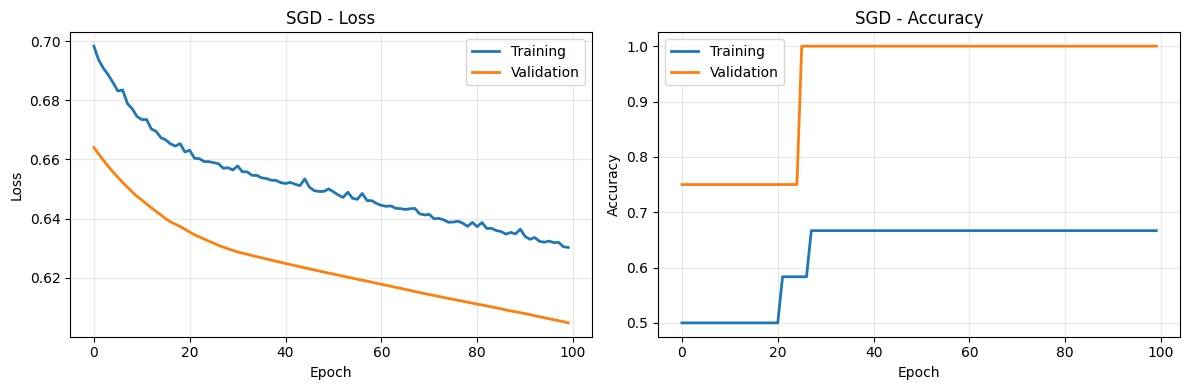

In [121]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (key, title) in zip(axes, [('loss', 'Loss'), ('accuracy', 'Accuracy')]):
    ax.plot(history.history[key], label='Training', linewidth=2)
    ax.plot(history.history[f'val_{key}'], label='Validation', linewidth=2)
    ax.set(xlabel='Epoch', ylabel=title, title=f'SGD - {title}')
    ax.legend(); 
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [122]:
# Helper function to train model
def train_model(activation=None, optimizer=None):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(8, activation=activation or 'relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer or 'sgd', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train.values, y_train.values, 
                        validation_data=(X_test.values, y_test.values),
                        epochs=100, batch_size=4, verbose=0)
    return model, history

In [123]:
# Train with different activations
activations = ['relu', 'tanh', 'linear']
hist_act = {name: train_model(activation=name)[1] for name in activations}

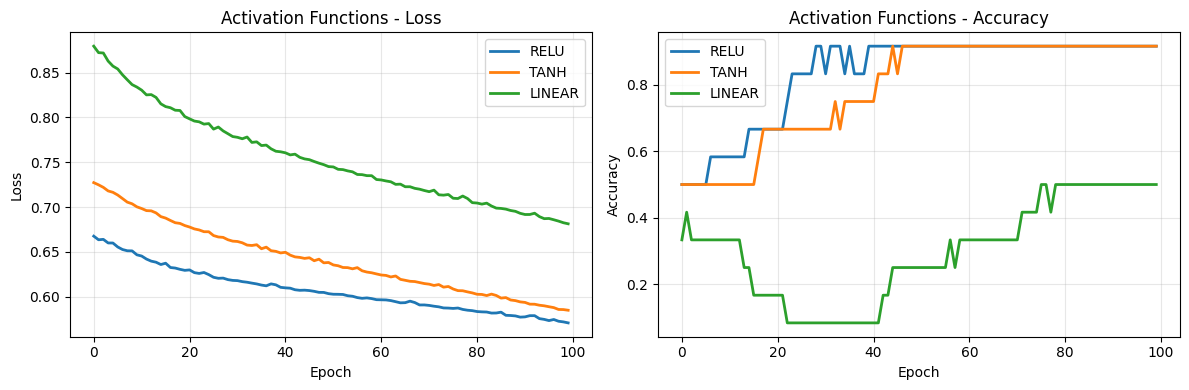

(None, None)

In [124]:
# Plot activation functions comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in activations:
    axes[0].plot(hist_act[name].history['loss'], label=name.upper(), linewidth=2)
    axes[1].plot(hist_act[name].history['accuracy'], label=name.upper(), linewidth=2)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Activation Functions - Loss')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Activation Functions - Accuracy')
axes[0].legend(), axes[0].grid(True, alpha=0.3)
axes[1].legend(), axes[1].grid(True, alpha=0.3)
plt.tight_layout(), plt.show()

In [125]:
# Train with different optimizers
optimizers = ['sgd', 'adam', 'rmsprop', 'adagrad']
hist_opt = {name: train_model(optimizer=name)[1] for name in optimizers}

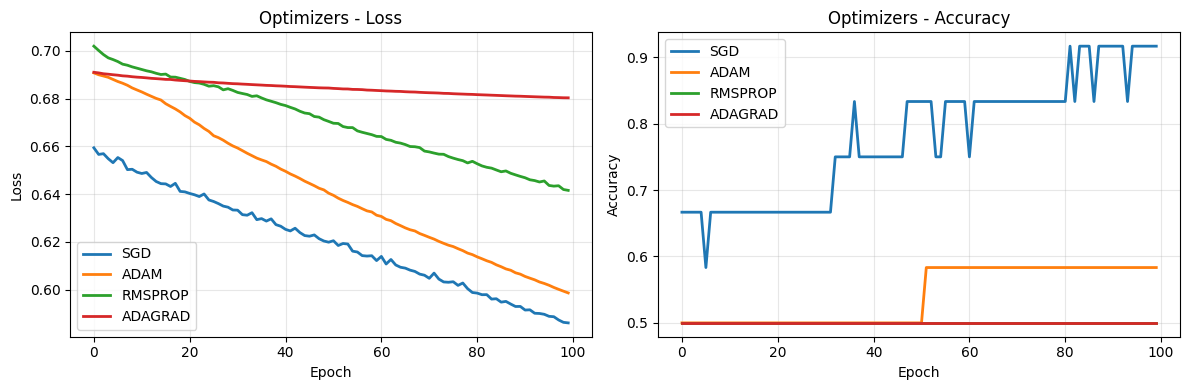

(None, None)

In [126]:
# Plot optimizers comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in optimizers:
    axes[0].plot(hist_opt[name].history['loss'], label=name.upper(), linewidth=2)
    axes[1].plot(hist_opt[name].history['accuracy'], label=name.upper(), linewidth=2)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Optimizers - Loss')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Optimizers - Accuracy')
axes[0].legend(), axes[0].grid(True, alpha=0.3)
axes[1].legend(), axes[1].grid(True, alpha=0.3)
plt.tight_layout(), plt.show()

In [127]:
# Final Summary
print("\nACTIVATION FUNCTIONS - Final Results:")
for name in activations:
    loss = hist_act[name].history['val_loss'][-1]
    acc = hist_act[name].history['val_accuracy'][-1]
    print(f"  {name.upper():8} Loss: {loss:.4f}, Accuracy: {acc:.4f}")

print("\nOPTIMIZERS - Final Results:")
for name in optimizers:
    loss = hist_opt[name].history['val_loss'][-1]
    acc = hist_opt[name].history['val_accuracy'][-1]
    print(f"  {name.upper():8} Loss: {loss:.4f}, Accuracy: {acc:.4f}")


ACTIVATION FUNCTIONS - Final Results:
  RELU     Loss: 0.5982, Accuracy: 1.0000
  TANH     Loss: 0.5620, Accuracy: 0.7500
  LINEAR   Loss: 0.6784, Accuracy: 0.5000

OPTIMIZERS - Final Results:
  SGD      Loss: 0.5852, Accuracy: 1.0000
  ADAM     Loss: 0.5831, Accuracy: 0.7500
  RMSPROP  Loss: 0.6560, Accuracy: 0.5000
  ADAGRAD  Loss: 0.6863, Accuracy: 0.7500
